# EDA — Suelo y geografía

Las capas **estáticas** que se sumaron al panel (SoilGrids v2.0 + SRTM + HydroSHEDS):
44 columnas de suelo y 4 de geografía, un valor por departamento que se repite en todas
sus campañas y cultivos. Este notebook es el **gate de decisión**: antes de comprometerlas
en el modelado hay que ver si aportan señal, y sobre todo *dónde*.

La pregunta no es solo "¿correlacionan con el rinde?" sino la más exigente: **¿aportan algo
por encima de `depto_enc`**, la codificación del departamento por su rinde medio de train
que el Componente B ya usa? Si suelo solo explicara el nivel medio de cada departamento,
sería redundante con esa feature y no valdría la pena.

Fuente y caveats de las capas: [`docs/fuentes_dataset.md`](../../docs/fuentes_dataset.md).

In [1]:
import os, sys, json, warnings
if os.path.basename(os.getcwd()) == "eda":
    os.chdir("..")                       # -> componente_a/
sys.path.insert(0, os.getcwd())          # para `from src import ...`
RAIZ = os.path.dirname(os.getcwd())      # raíz del repo
sys.path.insert(0, RAIZ)                 # para `from componente_b import ...`
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
plt.rcParams["figure.dpi"] = 110
pd.set_option("display.width", 200)

from src import data as cdata
from componente_b import datos, evaluacion as ev
from componente_b.modelos.xgboost_model import XGBoostRegressor

CULTIVOS = ["soja", "maiz"]
SEEDS = [42, 52, 62, 72, 82]
HP = json.load(open(os.path.join(RAIZ, "componente_b/experimentos/retuning_cv_honesta.json")))

panel_z = cdata.compute_z_rinde(cdata.load_panel())
panel_z, SUELO = cdata.add_suelo_features(panel_z)
print(f"panel: {panel_z.shape} | features derivadas de suelo/geo: {len(SUELO)}")

[data] dedup panel: 27865 -> 20672 filas (7193 duplicados espurios por lat/lon eliminados)
[data] clip rinde_kgha (0.5%/99.5% por cultivo): 98 filas afectadas


panel: (20672, 143) | features derivadas de suelo/geo: 13


## 1 · Cobertura y sanidad

Las 48 columnas crudas ya pasaron por `eda/validate_capas_estaticas.py` (rangos físicos,
texturas sumando 100 %, constancia por departamento). Acá solo se confirma lo que importa
para modelar: cobertura completa y que las **13 derivadas** de `add_suelo_features` tengan
valores plausibles.

In [2]:
filas = []
for col in SUELO:
    s = panel_z[col]
    filas.append({"feature": col, "nulos": int(s.isna().sum()),
                  "min": s.min(), "media": s.mean(), "max": s.max()})
pd.DataFrame(filas).set_index("feature").round(2)

,nulos,min,media,max
feature,,,,
suelo_awc_mm,0,3.40,78.56,133.37
suelo_awc_sup_mm,0,3.40,43.77,69.30
suelo_clay_sup,0,9.04,27.19,58.42
suelo_sand_sup,0,1.43,31.35,75.57
suelo_soc_sup,0,7.25,19.23,48.25
suelo_nitrogen_sup,0,7.62,16.82,35.19
suelo_phh2o_sup,0,4.95,6.71,7.80
suelo_cec_sup,0,14.84,21.19,28.54
suelo_bdod_sup,0,1.10,1.37,1.52


## 2 · Por qué `z_rinde` es el target equivocado para estas features

`z_rinde` se calcula con una media móvil **por departamento**: mide cuánto se desvía una
campaña respecto de la historia reciente *de ese mismo departamento*. Su media dentro de
cada departamento es ~0 por construcción.

Una feature estática no puede explicar nada de eso: vale lo mismo todos los años. Así que
la correlación fila-a-fila contra `z_rinde` tiene que dar ~0 **por construcción, no por
falta de señal**. Lo que sí puede explicar es el **nivel** de rinde: por qué un
departamento rinde más que otro.

In [3]:
filas = []
for cultivo in CULTIVOS:
    d = panel_z[(panel_z.cultivo == cultivo) & panel_z.z_rinde.notna()]
    fila_a_fila = d[SUELO].corrwith(d["z_rinde"]).abs()
    agg = d.groupby(["provincia", "departamento"]).agg(
        rinde_medio=("rinde_kgha", "mean"), **{c: (c, "first") for c in SUELO})
    nivel = agg[SUELO].corrwith(agg["rinde_medio"]).abs()
    filas.append({"cultivo": cultivo, "n_filas": len(d), "n_deptos": len(agg),
                  "|corr| máx vs z_rinde (fila)": fila_a_fila.max(),
                  "|corr| máx vs rinde medio (depto)": nivel.max()})
pd.DataFrame(filas).set_index("cultivo").round(3)

,n_filas,n_deptos,|corr| máx vs z_rinde (fila),|corr| máx vs rinde medio (depto)
cultivo,,,,
soja,8234,243,0.029,0.262
maiz,10778,301,0.040,0.444


La diferencia es de un orden de magnitud. **Conclusión operativa:** suelo y geografía
son features de *nivel entre departamentos*, no de *anomalía dentro del departamento*.

Esto explica además por qué **no sirven en el Componente A** tal como está: su pipeline
z-scorea cada feature por departamento, y una feature estática tiene varianza 0 dentro del
grupo, así que queda en exactamente 0 para todas las filas. El Componente B las aprovecha
porque escala global.

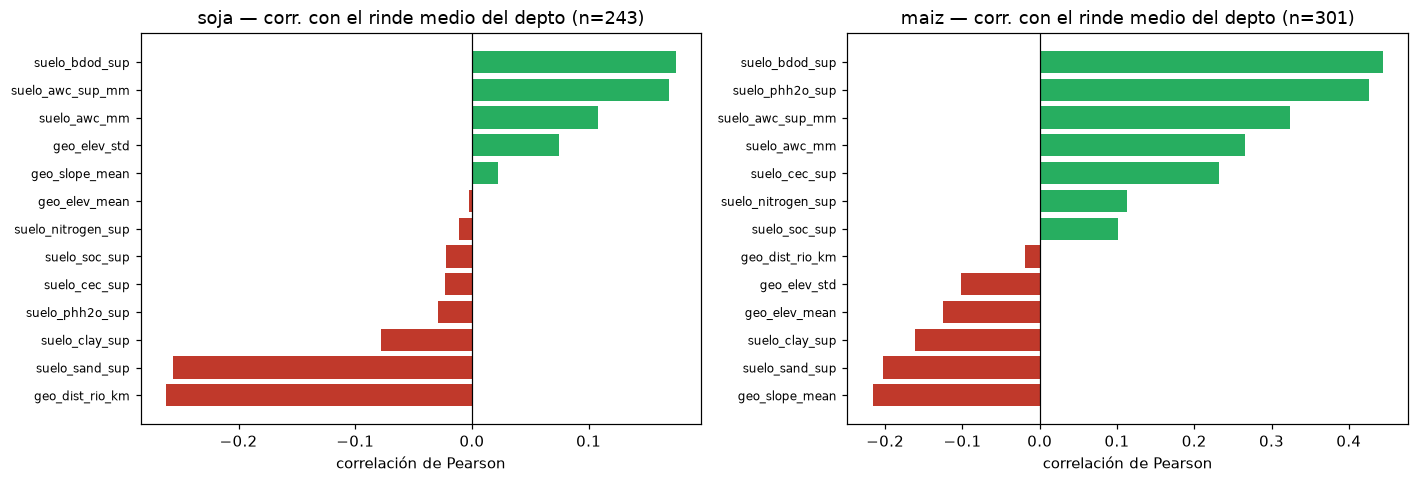

In [4]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))
for ax, cultivo in zip(axes, CULTIVOS):
    d = panel_z[(panel_z.cultivo == cultivo) & panel_z.z_rinde.notna()]
    agg = d.groupby(["provincia", "departamento"]).agg(
        rinde_medio=("rinde_kgha", "mean"), **{c: (c, "first") for c in SUELO})
    corr = agg[SUELO].corrwith(agg["rinde_medio"]).sort_values()
    colores = ["#c0392b" if v < 0 else "#27ae60" for v in corr]
    ax.barh(range(len(corr)), corr.values, color=colores)
    ax.set_yticks(range(len(corr))); ax.set_yticklabels(corr.index, fontsize=8)
    ax.axvline(0, color="k", lw=0.8)
    ax.set_title(f"{cultivo} — corr. con el rinde medio del depto (n={len(agg)})")
    ax.set_xlabel("correlación de Pearson")
plt.tight_layout(); plt.show()

## 3 · El gate: ¿aporta sobre lo que el modelo ya tiene?

La correlación sola no alcanza — el Componente B ya incluye `depto_enc` (rinde medio del
departamento en train), que captura el nivel departamental directamente. La prueba honesta
es entrenar **con y sin** las 13 features, todo lo demás igual, y comparar el RMSE de
validación cruzada walk-forward.

Se usan los hiperparámetros de XGBoost ya tuneados (`retuning_cv_honesta.json`) y **5
semillas**, porque con `subsample=0.7` una sola corrida no distingue señal de ruido.

In [5]:
filas = []
for cultivo in CULTIVOS:
    p = dict(HP[cultivo]["xgb"]["best_params"])
    res = {}
    for etiqueta, usar in [("sin", False), ("con", True)]:
        ds = datos.prepare(cultivo, use_agro=True, use_suelo=usar, enc_smooth=10.0)
        res[etiqueta] = np.array([ev.cv_score(XGBoostRegressor, {**p, "random_state": s},
                                              ds, n_splits=4) for s in SEEDS])
        res[f"n_{etiqueta}"] = len(ds.feature_cols)
    dif = res["sin"] - res["con"]
    filas.append({"cultivo": cultivo, "features": f"{res['n_sin']} -> {res['n_con']}",
                  "CV-RMSE sin": res["sin"].mean(), "±": res["sin"].std(),
                  "CV-RMSE con": res["con"].mean(), "± ": res["con"].std(),
                  "mejora": dif.mean(), "mejora %": 100 * dif.mean() / res["sin"].mean(),
                  "semillas a favor": f"{int((dif > 0).sum())}/{len(SEEDS)}"})
pd.DataFrame(filas).set_index("cultivo").round(2)

[data] dedup panel: 27865 -> 20672 filas (7193 duplicados espurios por lat/lon eliminados)


[data] dedup panel: 27865 -> 20672 filas (7193 duplicados espurios por lat/lon eliminados)


[data] dedup panel: 27865 -> 20672 filas (7193 duplicados espurios por lat/lon eliminados)


[data] dedup panel: 27865 -> 20672 filas (7193 duplicados espurios por lat/lon eliminados)


,features,CV-RMSE sin,±,CV-RMSE con,±,mejora,mejora %,semillas a favor
cultivo,,,,,,,,
soja,78 -> 91,624.08,0.76,621.96,0.95,2.12,0.34,5/5
maiz,78 -> 91,1465.56,4.14,1451.40,2.73,14.16,0.97,5/5


## 4 · Dónde aporta: contribución por momento de la campaña

Si la hipótesis agronómica es correcta, el suelo debería pesar **más cuanto menos clima
observado haya**: en pre-siembra el modelo casi no tiene información de la campaña en
curso, así que la capacidad de retención de agua del suelo es de lo poco que lo orienta.
Sobre el final, con toda la campaña observada, el clima ya explica casi todo.

Este es el chequeo que conecta con la Parte 2 del plan (checkpoints).

In [6]:
filas = []
for cultivo in CULTIVOS:
    p = dict(HP[cultivo]["xgb"]["best_params"])
    for momento in ["pre_siembra", "pre_cosecha", "full"]:
        vals = {}
        for etiqueta, usar in [("sin", False), ("con", True)]:
            kw = dict(momento=momento, use_suelo=usar, enc_smooth=10.0)
            if momento == "full":
                kw["use_agro"] = True      # las agronómicas usan clima hasta marzo
            ds = datos.prepare(cultivo, **kw)
            vals[etiqueta] = np.mean([ev.cv_score(XGBoostRegressor,
                                                  {**p, "random_state": s}, ds, n_splits=4)
                                      for s in SEEDS[:3]])
            vals[f"n_{etiqueta}"] = len(ds.feature_cols)
        filas.append({"cultivo": cultivo, "momento": momento,
                      "features": f"{vals['n_sin']} -> {vals['n_con']}",
                      "sin": vals["sin"], "con": vals["con"],
                      "mejora %": 100 * (vals["sin"] - vals["con"]) / vals["sin"]})
tabla = pd.DataFrame(filas).set_index(["cultivo", "momento"])
tabla.round(2)

[data] dedup panel: 27865 -> 20672 filas (7193 duplicados espurios por lat/lon eliminados)


[data] dedup panel: 27865 -> 20672 filas (7193 duplicados espurios por lat/lon eliminados)


[data] dedup panel: 27865 -> 20672 filas (7193 duplicados espurios por lat/lon eliminados)


[data] dedup panel: 27865 -> 20672 filas (7193 duplicados espurios por lat/lon eliminados)


[data] dedup panel: 27865 -> 20672 filas (7193 duplicados espurios por lat/lon eliminados)


...

[data] dedup panel: 27865 -> 20672 filas (7193 duplicados espurios por lat/lon eliminados)


[data] dedup panel: 27865 -> 20672 filas (7193 duplicados espurios por lat/lon eliminados)


[data] dedup panel: 27865 -> 20672 filas (7193 duplicados espurios por lat/lon eliminados)


[data] dedup panel: 27865 -> 20672 filas (7193 duplicados espurios por lat/lon eliminados)


features      sin      con  mejora %
cultivo momento                                          
soja    pre_siembra   8 -> 21   697.69   687.68      1.43
        pre_cosecha  64 -> 77   631.61   629.02      0.41
        full         78 -> 91   623.89   622.18      0.27
maiz    pre_siembra   8 -> 21  1609.26  1556.87      3.26
        pre_cosecha  64 -> 77  1458.20  1440.71      1.20
        full         78 -> 91  1466.92  1452.68      0.97

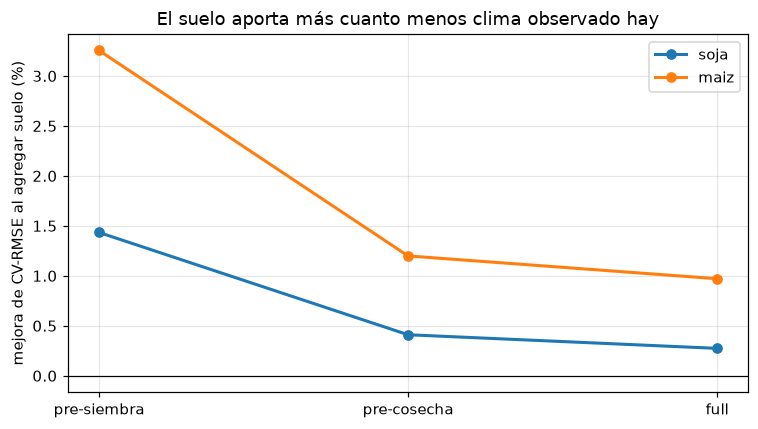

In [7]:
fig, ax = plt.subplots(figsize=(7, 4))
for cultivo in CULTIVOS:
    sub = tabla.loc[cultivo]
    ax.plot(range(len(sub)), sub["mejora %"], "o-", label=cultivo, lw=2)
ax.set_xticks(range(3)); ax.set_xticklabels(["pre-siembra", "pre-cosecha", "full"])
ax.set_ylabel("mejora de CV-RMSE al agregar suelo (%)")
ax.set_title("El suelo aporta más cuanto menos clima observado hay")
ax.axhline(0, color="k", lw=0.8); ax.legend(); ax.grid(alpha=0.3)
plt.tight_layout(); plt.show()

## Conclusión

**El gate se pasa, con matices.**

1. **Suelo y geografía son features de nivel, no de anomalía.** Su correlación fila-a-fila
   con `z_rinde` es ~0.03 (nula por construcción, porque `z_rinde` está normalizado por
   departamento), pero contra el rinde medio departamental llega a 0.44 en maíz
   (`bdod`, `phh2o`, agua útil). Hay señal, pero solo en la dimensión *entre* departamentos.

2. **No sirven en el Componente A** tal como está construido. Su normalización por
   departamento las anula: varianza 0 dentro del grupo → exactamente 0 en todas las filas.
   Aprovecharlas ahí exigiría cambiar el esquema de normalización, que no está en el
   alcance de esta iteración. **El ablation de suelo va en el Componente B.**

3. **Aportan por encima de `depto_enc`**, que era la duda de fondo. La mejora es chica
   pero sistemática: soja +0.34 %, maíz +0.97 % de CV-RMSE, ganando en **5 de 5 semillas**
   en ambos cultivos, con una magnitud que supera holgadamente el ruido entre semillas
   (en maíz, ~6 desvíos). No es un salto, pero no es ruido.

4. **El aporte se concentra donde más se lo necesita.** El gradiente es monótono y va en la
   dirección que predice la agronomía: pre-siembra +1.4 % (soja) y +3.3 % (maíz), contra
   +0.3 % y +1.0 % con la campaña completa. En pre-siembra el modelo pasa de 8 a 21
   features, y es justo el momento en que un productor decide qué sembrar sin tener
   todavía ningún dato de clima. Para el caso de uso de producto, es el resultado más
   relevante del notebook.

**Decisión:** las capas estáticas entran al Componente B, con `use_suelo=True`, y hay que
prestarles atención especial en los checkpoints tempranos de la Parte 2.

**Caveat obligatorio.** SoilGrids tiene habilidad local limitada en Argentina: sobreestima
el carbono orgánico ~2.4× frente a estimaciones país-específicas (Guevara et al. 2018), y
lo mismo se ve en el nitrógeno de los suelos hidromórficos de la bahía de Samborombón
(~80 g/kg). Estas variables valen como **gradiente relativo entre departamentos**, que es
exactamente el uso que se les está dando acá — no como valor absoluto de campo.